## DBSCAN Clustering - Mall Customers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used to scale features because DBSCAN is distance-based
from sklearn.preprocessing import StandardScaler

# Used to create the K-Distance Graph for choosing eps
from sklearn.neighbors import NearestNeighbors

# DBSCAN algorithm
from sklearn.cluster import DBSCAN


In [2]:
df = pd.read_csv("Mall_Customers.csv")

# Display first five records
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Missing values
print(df.isnull().sum())

# Information
print(df.info())

# Statistical summary
print(df.describe())


Shape: (200, 5)
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())


   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [5]:
scaler = StandardScaler()

# Convert data to mean=0 and std=1
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


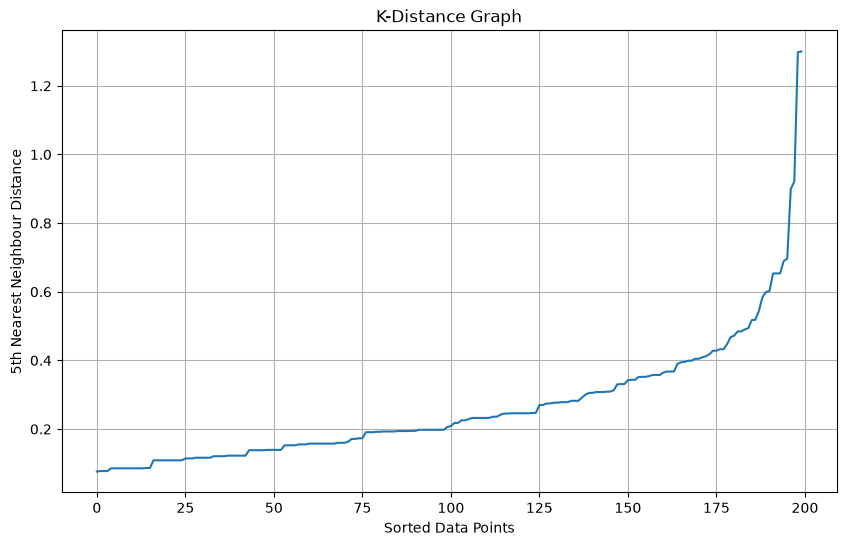

In [6]:
neighbors = NearestNeighbors(n_neighbors=5)

# Store the scaled data
neighbors_fit = neighbors.fit(X_scaled)

# Find neighbour distances
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take only the distance to the 5th nearest neighbour
distances = distances[:,4]

# Sort distances for plotting
distances = np.sort(distances)

plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Sorted Data Points")
plt.ylabel("5th Nearest Neighbour Distance")
plt.grid(True)
plt.show()


In [7]:
print("Distances:")
print(distances)

# Print the indices
print("\nIndices:")
print(indices)

Distances:
[0.07633886 0.07764312 0.07764312 0.07764312 0.08564307 0.08564307
 0.08564307 0.08564307 0.08564307 0.08564307 0.08564307 0.08564307
 0.08564307 0.08564307 0.08651797 0.08651797 0.10888561 0.10888561
 0.10888561 0.10888561 0.10888561 0.10888561 0.10888561 0.10888561
 0.10888561 0.11450829 0.11450829 0.11450829 0.11646468 0.11646468
 0.11646468 0.11646468 0.11646468 0.12091014 0.12091014 0.12091014
 0.12091014 0.12255989 0.12255989 0.12255989 0.12255989 0.12255989
 0.12255989 0.13834957 0.13834957 0.13834957 0.13834957 0.13834957
 0.13925388 0.13925388 0.13925388 0.13925388 0.13925388 0.15267772
 0.15267772 0.15267772 0.15267772 0.15528624 0.15528624 0.15528624
 0.15753602 0.15753602 0.15753602 0.15753602 0.15753602 0.15753602
 0.15753602 0.15753602 0.15990848 0.15990848 0.15990848 0.16332841
 0.17128613 0.17128613 0.17303595 0.17303595 0.19084715 0.19084715
 0.19084715 0.19202736 0.19202736 0.19294031 0.19294031 0.19294031
 0.19294031 0.1941078  0.1941078  0.1941078  0.1941

In [8]:
distance_df = pd.DataFrame({
    "Customer Index": range(len(distances)),
    "Distance to 5th Nearest Neighbour": distances
})

print(distance_df.head(10))

   Customer Index  Distance to 5th Nearest Neighbour
0               0                           0.076339
1               1                           0.077643
2               2                           0.077643
3               3                           0.077643
4               4                           0.085643
5               5                           0.085643
6               6                           0.085643
7               7                           0.085643
8               8                           0.085643
9               9                           0.085643


In [9]:
dbscan = DBSCAN(
    eps=0.4,      # Maximum neighbour distance
    min_samples=5  # Minimum points required to form a dense region
)

In [10]:
clusters = dbscan.fit_predict(X_scaled)

# Store cluster labels
df["Cluster"] = clusters

print(df.head())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        1  
3        0  
4        0  


In [11]:
print(df['Cluster'].value_counts().sort_index())

# Number of clusters (ignore -1)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Number of clusters:", n_clusters)

# Count noise points
noise = list(clusters).count(-1)
print("Noise points:", noise)


Cluster
-1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64
Number of clusters: 4
Noise points: 15


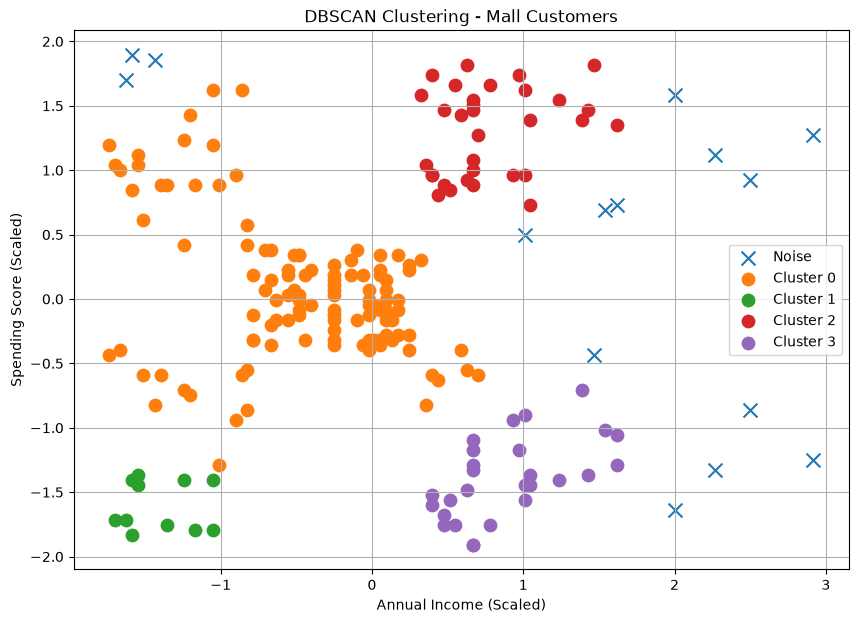

In [12]:
plt.figure(figsize=(10,7))

unique_clusters = np.unique(clusters)

for cluster in unique_clusters:

    cluster_points = X_scaled[clusters == cluster]

    if cluster == -1:
        # Noise points
        plt.scatter(cluster_points[:,0],
                    cluster_points[:,1],
                    marker='x',
                    s=100,
                    label='Noise')
    else:
        # Cluster points
        plt.scatter(cluster_points[:,0],
                    cluster_points[:,1],
                    s=80,
                    label=f'Cluster {cluster}')

plt.title("DBSCAN Clustering - Mall Customers")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
summary = df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print(summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
-1                96.133333               61.800000
 0                48.304348               51.730435
 1                23.727273                8.909091
 2                80.875000               83.625000
 3                83.925926               14.444444


# DBSCAN Algorithm - Complete Workflow

## Step 1: Load the Dataset
- Load the dataset into Python.

---

## Step 2: Explore the Dataset
- Check the dataset shape.
- Display the first and last few records.
- Check data types.
- Check for missing values.
- Display summary statistics.

---

## Step 3: Select the Features
- Choose the numerical features required for clustering.
- Example:
  - Annual Income
  - Spending Score

---

## Step 4: Scale the Features
- Standardize the selected features.
- Scaling ensures that all features contribute equally during distance calculations.

---

## Step 5: Choose `min_samples`
- Decide the minimum number of neighbours required to form a dense region.
- Example:
  - `min_samples = 5`

---

## Step 6: Apply K-Nearest Neighbours (KNN)
- Set **K = min_samples**.
- Find the K nearest neighbours for every data point.
- **Purpose:** Estimate a suitable value for `eps`.
- **Note:** KNN is **not used for clustering**.

---

## Step 7: Calculate the Kth Nearest Neighbour Distance
- For every point, record only the distance to its Kth nearest neighbour.
- This distance indicates how far we need to travel from a point to include K neighbours.

---

## Step 8: Sort the Distances
- Arrange the Kth nearest neighbour distances in ascending order.
- Sorting creates a smooth graph, making it easier to identify the elbow point.

---

## Step 9: Plot the K-Distance Graph
- X-axis → Sorted Data Points
- Y-axis → Distance to the Kth Nearest Neighbour

---

## Step 10: Identify the Elbow Point
- Find the point where the graph changes from a gradual increase to a sharp increase.
- This point represents the transition between dense regions and sparse regions.

---

## Step 11: Choose the `eps` Value
- Select the distance corresponding to the elbow point.
- This becomes the neighbourhood radius (`eps`) for DBSCAN.

---

# Actual DBSCAN Algorithm Begins

## Step 12: Create the DBSCAN Model
- Initialize the DBSCAN algorithm using:
  - Selected `eps`
  - Selected `min_samples`

---

## Step 13: Fit the DBSCAN Model
- Run the DBSCAN algorithm on the scaled dataset.

---

## Step 14: Select the First Unvisited Point
- Start with the first unvisited data point.

---

## Step 15: Draw an Imaginary `eps` Circle
- Imagine drawing a circle of radius `eps` around the selected point.
- This circle represents the neighbourhood of that point.

---

## Step 16: Count the Neighbours
- Count the number of points inside the `eps` circle.
- Include the selected point itself.

---

## Step 17: Identify the Point Type
- If **Neighbours ≥ min_samples**
  - Mark the point as a **Core Point**.
- Otherwise
  - Continue checking whether it is a Border Point or Noise Point.

---

## Step 18: Create a New Cluster
- If the selected point is a Core Point, create a new cluster.

---

## Step 19: Expand the Cluster
- Add all neighbouring points to the cluster.
- Visit each neighbour.
- If a neighbour is also a Core Point, add all of its neighbours as well.
- Continue until no more points can be added.

---

## Step 20: Identify Border Points
- A Border Point:
  - Has fewer than `min_samples` neighbours.
  - Lies inside the `eps` neighbourhood of a Core Point.
- Border Points belong to a cluster but do not expand it.

---

## Step 21: Identify Noise Points
- A Noise Point:
  - Has fewer than `min_samples` neighbours.
  - Does not lie inside the `eps` neighbourhood of any Core Point.
- Assign the cluster label **-1**.

---

## Step 22: Repeat the Process
- Move to the next unvisited point.
- Repeat the same procedure until all points have been processed.

---

## Step 23: Store the Cluster Labels
- Save the cluster assigned to each data point.
- Noise points receive the label **-1**.

---

## Step 24: Visualize the Clusters
- Plot the clusters using different colours.
- Display Noise points separately using a different colour or marker.

---

## Step 25: Analyze the Results
- Count the number of clusters.
- Count the number of Noise points.
- Calculate summary statistics for each cluster.
- Interpret the characteristics of each cluster.